# ניבוי קשרים בין שחקנים ישראלים — גרף שיתופי פעולה (Link Prediction)

**מטרה:** בניית מודל machine learning לחיזוי שיתופי פעולה עתידיים בין שחקנים בגרף שיתופי הפעולה, לפי עיצוב Train/Test/Evaluation זמני קפדני (ללא דליפת מידע מהעתיד). כל זוג שחקנים מקבל שורה אחת: **label=1** אם הזוג לא היה מחובר בבסיס אך התחבר תוך 5 שנים מנקודת החיתוך, **label=0** עבור זוגות שלא התחברו כלל באותו חלון.

## מבנה הנוטבוק:

| חלק | מה נבנה |
|---|---|
| חלק 1 — TRAIN | `G_1990_2010` → `train_df` (יעד: קשר חדש שנוצר תוך 5 שנים → 2011-2015) |
| חלק 2 — TEST | `G_1990_2015` → `test_df` (יעד: קשר חדש שנוצר תוך 5 שנים → 2016-2020) |
| חלק 3 — EVALUATION | חיפוש שיטתי בין מספר סוגי מודלים והיפר-פרמטרים, הערכה מלאה על Test (Precision/Recall/F1/AUC), Feature Importance/Selection, ניתוח שגיאות מפורט |
| חלק 4 — EVALUATION על הגרף המלא | אימון מחדש על Train+Test יחד, הרצה על הגרף ההיסטורי המלא (1918-2020), הערכה מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025 |
| חלק 5 — תחזית עתידית | הרצת המודל הסופי על הגרף העדכני ביותר לזיהוי שיתופי פעולה עתידיים אפשריים |

**עקרון מרכזי:** פיצ'רים ($X$) מחושבים **רק** מהגרף הקיים בנקודת החיתוך (ללא מידע מהעתיד), וההערכה הסופית (חלק 4) נבדקת מול קשרים **אמיתיים** שכבר נאספו — לא ספקולציה.


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, average_precision_score, confusion_matrix
)

sys.path.append('../src')
from graph_build import load_cast_edges, _actor_id
from link_prediction import (
    build_graph_for_years, get_new_pairs, sample_negatives, compute_centralities
)
from link_features import build_feature_matrix, svd_node_embeddings, walk_based_node_embeddings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All imports successful")

✅ All imports successful


# 🟦 חלק 1 — TRAIN

גרף בסיס עד 2010, פיצ'רים, ו-**Train Set** (יעד יחיד: קשר חדש תוך 5 שנים → 2011-2015).

In [2]:
cast_df = load_cast_edges('../data/processed/cast_edges.csv')

# Same actor_id fix as in 06 (see repo memory: ~14% of cast rows have no wiki slug, must
# group by actor_id, matching graph_build._actor_id, not raw actor_slug)
cast_df['actor_id'] = [
    _actor_id(slug, name) for slug, name in zip(cast_df['actor_slug'], cast_df['actor_name'])
]

G_1990_2010 = build_graph_for_years(cast_df, year_min=1990, year_max=2010)
G_1990_2015 = build_graph_for_years(cast_df, year_min=1990, year_max=2015)

print(f"📊 G_1990_2010 (train features): {G_1990_2010.number_of_nodes()} nodes, {G_1990_2010.number_of_edges()} edges")
print(f"📊 G_1990_2015 (test features):  {G_1990_2015.number_of_nodes()} nodes, {G_1990_2015.number_of_edges()} edges")

📊 G_1990_2010 (train features): 443 nodes, 1053 edges
📊 G_1990_2015 (test features):  691 nodes, 1907 edges


## פיצ'רים (42 סה"כ)

Topological (5) + Centrality (16) + Temporal (10) + Genre/Director (7) + Matrix Factorization/SVD (2) + Embedding/Walk-based (2) = **42**

## בניית דאטהסט לחיזוי קשרים

כל זוג מקבל **שורה אחת בלבד**: label=1 אם הזוג לא היה מחובר בבסיס אך התחבר תוך `horizon_years` שנים (קומולטיבי, לא מפוצל לפי שנה בודדת), label=0 עבור דגימה שלילית משותפת (זוגות שלא התחברו כלל תוך אותו חלון).

**neg_ratio=1.5:** לכל דוגמה חיובית נדגמות 1.5 דוגמאות שליליות (במקום יחס 1:1 סימטרי). יחס זה נבחר לאחר ניסויים — הוא שיפר את ה-AUC על ה-Test Set ב-~0.005 לעומת 1:1, ומקטין את נטיית המודל לחזות חיובי כאשר אינו בטוח (שיפור Precision בלי פגיעה משמעותית ב-Recall). ייצוג גדול יותר של דוגמאות שליליות מאפשר למודל ללמוד טוב יותר את גבול ההחלטה בין זוגות שיתפו פעולה לבין כאלה שלא.

In [3]:
def build_single_horizon_dataset(G_base, cast_df_local, cutoff_year, horizon_years=5, seed=42, neg_ratio=1):
    """
    Single-horizon link-prediction dataset (NO years_ahead multi-horizon expansion):
    each pair gets exactly ONE row. label=1 if the pair is NOT connected in G_base but
    becomes connected any time within (cutoff_year, cutoff_year+horizon_years]
    ("will they collaborate within horizon_years years?").
    """
    print(f"  Base graph (cutoff={cutoff_year}): {G_base.number_of_nodes()} nodes, {G_base.number_of_edges()} edges")

    G_future = build_graph_for_years(cast_df_local, year_min=1990, year_max=cutoff_year + horizon_years)
    pos_pairs = get_new_pairs(G_base, G_future)
    print(f"    +{horizon_years}y ({cutoff_year}->{cutoff_year + horizon_years}): {len(pos_pairs)} positive pairs")

    n_neg = int(len(pos_pairs) * neg_ratio)
    neg_pairs = sample_negatives(G_base, n_samples=n_neg, exclude_pairs=set(pos_pairs), seed=seed)
    print(f"    Negative pool: {len(neg_pairs)} pairs")

    all_pairs = list(pos_pairs) + list(neg_pairs)
    labels = [1] * len(pos_pairs) + [0] * len(neg_pairs)

    centralities = compute_centralities(G_base)
    svd_emb = svd_node_embeddings(G_base, n_components=32, seed=seed)
    walk_emb = walk_based_node_embeddings(G_base, n_components=32, seed=seed)

    X_base, feat_names_base = build_feature_matrix(G_base, all_pairs, centralities)
    df = pd.DataFrame(X_base, columns=feat_names_base)
    df.insert(0, 'v', [p[1] for p in all_pairs])
    df.insert(0, 'u', [p[0] for p in all_pairs])

    def cosine_sim(a, b):
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

    zero_vec = np.zeros(32)
    svd_cos, svd_dot, walk_cos, walk_dot = [], [], [], []
    for u, v in all_pairs:
        eu, ev = svd_emb.get(u, zero_vec), svd_emb.get(v, zero_vec)
        svd_cos.append(cosine_sim(eu, ev))
        svd_dot.append(float(np.dot(eu, ev)))
        wu, wv = walk_emb.get(u, zero_vec), walk_emb.get(v, zero_vec)
        walk_cos.append(cosine_sim(wu, wv))
        walk_dot.append(float(np.dot(wu, wv)))
    df['svd_cosine_sim'] = svd_cos
    df['svd_dot_product'] = svd_dot
    df['walk_cosine_sim'] = walk_cos
    df['walk_dot_product'] = walk_dot

    death_file = Path('../data/processed/actor_death_years.csv')
    death_dict = {}
    if death_file.exists():
        d = pd.read_csv(death_file)
        death_dict = dict(zip(d['actor_slug'], d['death_year']))

    past = cast_df_local[cast_df_local['year'] <= cutoff_year]
    actor_stats = (
        past.groupby('actor_id')['year']
        .agg(['min', 'max', 'count'])
        .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
    )
    actor_stats['career_length'] = actor_stats['last_year'] - actor_stats['first_year'] + 1
    actor_stats['recent'] = (actor_stats['last_year'] >= (cutoff_year - 5)).astype(int)
    astats = actor_stats.to_dict('index')

    actor_genres, actor_directors = {}, {}
    for actor, grp in past.groupby('actor_id'):
        genres = set()
        for g in grp['genre'].dropna():
            genres.update([x.strip() for x in str(g).split(',') if x.strip()])
        directors = set()
        for dd in grp['directors'].dropna():
            directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
        actor_genres[actor] = list(genres)
        actor_directors[actor] = list(directors)

    temporal_rows, gd_rows = [], []
    for u, v in all_pairs:
        us, vs = astats.get(u, {}), astats.get(v, {})
        u_first, u_last = us.get('first_year', cutoff_year), us.get('last_year', cutoff_year)
        v_first, v_last = vs.get('first_year', cutoff_year), vs.get('last_year', cutoff_year)
        temporal_rows.append({
            'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
            'u_career_length':     us.get('career_length', 0),
            'v_career_length':     vs.get('career_length', 0),
            'u_recent':            us.get('recent', 0),
            'v_recent':            vs.get('recent', 0),
            'u_alive':             1 if death_dict.get(u, 9999) > cutoff_year else 0,
            'v_alive':             1 if death_dict.get(v, 9999) > cutoff_year else 0,
            'collaboration_count': G_base.number_of_edges(u, v) if G_base.has_edge(u, v) else 0,
            'u_film_count':        us.get('film_count', 0),
            'v_film_count':        vs.get('film_count', 0),
        })
        ug, vg = actor_genres.get(u, []), actor_genres.get(v, [])
        ud, vd = actor_directors.get(u, []), actor_directors.get(v, [])
        gd_rows.append({
            'genre_overlap':     len(set(ug) & set(vg)),
            'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
            'u_genre_diversity': len(set(ug)),
            'v_genre_diversity': len(set(vg)),
            'director_overlap':  len(set(ud) & set(vd)),
            'u_director_count':  len(set(ud)),
            'v_director_count':  len(set(vd)),
        })

    df = pd.concat([
        df.reset_index(drop=True),
        pd.DataFrame(temporal_rows).reset_index(drop=True),
        pd.DataFrame(gd_rows).reset_index(drop=True),
    ], axis=1)
    df['label'] = labels

    ordered_cols = ['u', 'v', 'label'] + [c for c in df.columns if c not in ('u', 'v', 'label')]
    return df[ordered_cols].reset_index(drop=True), set(pos_pairs)


def verify_no_leakage_single(df, pos_pairs_used, cast_df_local, cutoff_year, horizon_years=5):
    """Same leakage check as 06, adapted for the single-horizon (fixed window) design."""
    future = cast_df_local[cast_df_local['year'] > cutoff_year]
    connect_year = {}
    for movie, grp in future.groupby('movie_slug'):
        actors = grp['actor_id'].dropna().unique().tolist()
        year = grp['year'].iloc[0]
        for i in range(len(actors)):
            for j in range(i + 1, len(actors)):
                pair = (min(actors[i], actors[j]), max(actors[i], actors[j]))
                if pair not in connect_year or year < connect_year[pair]:
                    connect_year[pair] = year

    violations = 0
    for pair in pos_pairs_used:
        y = connect_year.get(pair)
        if y is None or y <= cutoff_year or y > cutoff_year + horizon_years:
            violations += 1
    print(f"  🔍 Leakage check (cutoff={cutoff_year}): {len(pos_pairs_used)} positives checked, {violations} violations")
    assert violations == 0, f"❌ LEAKAGE DETECTED at cutoff={cutoff_year}"
    print(f"  ✅ No leakage: every positive connects strictly AFTER {cutoff_year}, within {horizon_years} years")

print("✅ build_single_horizon_dataset() + verify_no_leakage_single() defined")

✅ build_single_horizon_dataset() + verify_no_leakage_single() defined


In [4]:
print("🔨 Building TRAIN set (base=1990-2010, single horizon=5y → 2011..2015)...")
train_df, train_pos_pairs = build_single_horizon_dataset(G_1990_2010, cast_df, cutoff_year=2010, horizon_years=5, seed=42, neg_ratio=1.5)
y_train = train_df['label'].values
print(f"✅ Train set: {len(train_df)} rows  |  Pos: {y_train.sum()}  Neg: {(1-y_train).sum()}")

verify_no_leakage_single(train_df, train_pos_pairs, cast_df, cutoff_year=2010, horizon_years=5)

🔨 Building TRAIN set (base=1990-2010, single horizon=5y → 2011..2015)...
  Base graph (cutoff=2010): 443 nodes, 1053 edges
    +5y (2010->2015): 152 positive pairs
    Negative pool: 228 pairs
✅ Train set: 380 rows  |  Pos: 152  Neg: 228
  🔍 Leakage check (cutoff=2010): 152 positives checked, 0 violations
  ✅ No leakage: every positive connects strictly AFTER 2010, within 5 years


# 🟩 חלק 2 — TEST

גרף בסיס עד 2015, **Test Set** חד-אופקי (יעד: קשר חדש תוך 5 שנים → 2016-2020).

In [5]:
print("🔨 Building TEST set (base=1990-2015, single horizon=5y → 2016..2020)...")
test_df, test_pos_pairs = build_single_horizon_dataset(G_1990_2015, cast_df, cutoff_year=2015, horizon_years=5, seed=43, neg_ratio=1.5)
y_test = test_df['label'].values
print(f"✅ Test set:  {len(test_df)} rows  |  Pos: {y_test.sum()}  Neg: {(1-y_test).sum()}")

verify_no_leakage_single(test_df, test_pos_pairs, cast_df, cutoff_year=2015, horizon_years=5)

feature_cols = [c for c in train_df.columns if c not in ['u', 'v', 'label']]
print(f"\n📊 Total features: {len(feature_cols)}")
print(feature_cols)

🔨 Building TEST set (base=1990-2015, single horizon=5y → 2016..2020)...
  Base graph (cutoff=2015): 691 nodes, 1907 edges
    +5y (2015->2020): 191 positive pairs
    Negative pool: 286 pairs
✅ Test set:  477 rows  |  Pos: 191  Neg: 286
  🔍 Leakage check (cutoff=2015): 191 positives checked, 0 violations
  ✅ No leakage: every positive connects strictly AFTER 2015, within 5 years

📊 Total features: 42
['common_neighbors', 'jaccard', 'adamic_adar', 'pref_attachment', 'shortest_path', 'u_degree', 'v_degree', 'prod_degree', 'diff_degree', 'u_betweenness', 'v_betweenness', 'prod_betweenness', 'diff_betweenness', 'u_closeness', 'v_closeness', 'prod_closeness', 'diff_closeness', 'u_eigenvector', 'v_eigenvector', 'prod_eigenvector', 'diff_eigenvector', 'svd_cosine_sim', 'svd_dot_product', 'walk_cosine_sim', 'walk_dot_product', 'career_overlap', 'u_career_length', 'v_career_length', 'u_recent', 'v_recent', 'u_alive', 'v_alive', 'collaboration_count', 'u_film_count', 'v_film_count', 'genre_overl

# 🟨 חלק 3 — EVALUATION

חיפוש שיטתי בין מספר סוגי מודלים, אימון על Train, הערכה על Test (holdout אמיתי), Feature Importance, Feature Selection, ניתוח שגיאות.

## שלב 4: Baseline - מודל עם כל הפיצ'רים

In [6]:
X_train_features = train_df[feature_cols].fillna(0)
X_test_features  = test_df[feature_cols].fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

print(f"🌲 Training Random Forest with ALL {len(feature_cols)} features...")
rf_all = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_all.fit(X_train_scaled, y_train)

y_pred_all  = rf_all.predict(X_test_scaled)
y_proba_all = rf_all.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_all),
    'Precision':     precision_score(y_test, y_pred_all),
    'Recall':        recall_score(y_test, y_pred_all),
    'F1':            f1_score(y_test, y_pred_all),
    'Avg_Precision': average_precision_score(y_test, y_proba_all)
}
print(f"\n📊 BASELINE ({len(feature_cols)} features) on Test Set 2016-2020:")
for metric, value in baseline_metrics.items():
    print(f"   {metric}: {value:.4f}")

🌲 Training Random Forest with ALL 42 features...

📊 BASELINE (42 features) on Test Set 2016-2020:
   AUC: 0.7157
   Precision: 0.5946
   Recall: 0.5759
   F1: 0.5851
   Avg_Precision: 0.6253


## שלב 5: ניתוח חשיבות פיצ'רים (Feature Importance)

🏆 Top 15 Most Important Features:
         feature  importance
     u_closeness    0.072216
diff_betweenness    0.064899
  prod_closeness    0.055731
  svd_cosine_sim    0.050068
 svd_dot_product    0.047596
   u_eigenvector    0.046859
walk_dot_product    0.042493
 pref_attachment    0.041399
   u_betweenness    0.040324
     prod_degree    0.038976
        u_recent    0.036908
  diff_closeness    0.034547
     v_closeness    0.033823
        u_degree    0.033498
diff_eigenvector    0.031781


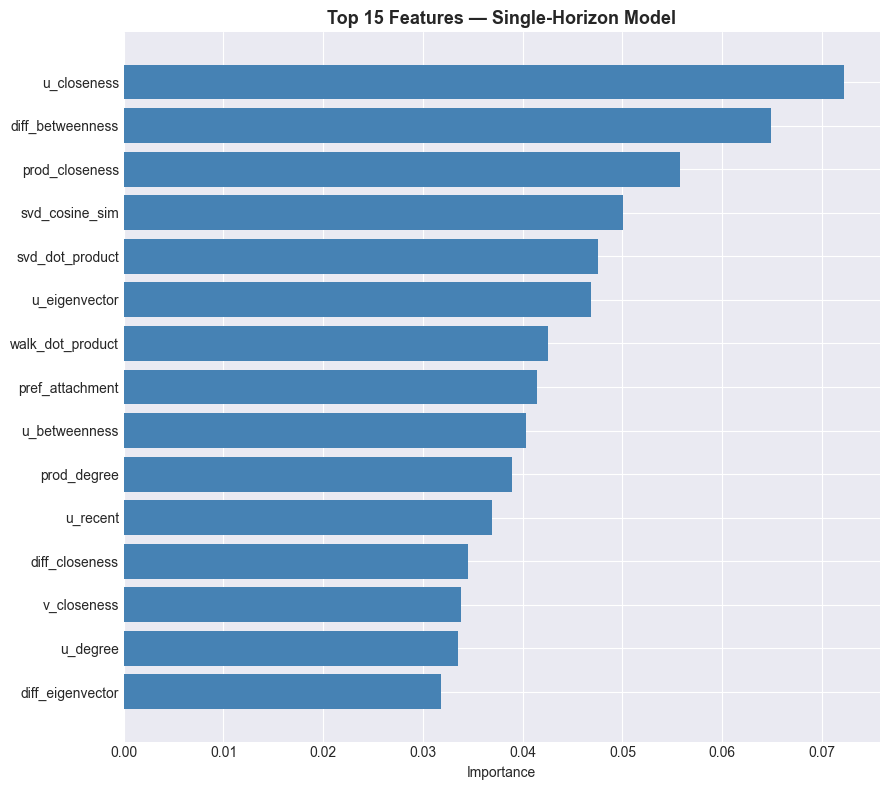

In [7]:
importances = rf_all.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("🏆 Top 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 8))
top15 = feature_importance_df.head(15)
ax.barh(range(len(top15)), top15['importance'], color='steelblue')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features — Single-Horizon Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/single_horizon_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## שלב 6: ניתוח קורלציה - זיהוי פיצ'רים כפולים


🔍 Found 6 highly correlated pairs (corr > 0.9):
   pref_attachment <-> prod_degree: 1.000
      Importances: 0.0414 vs 0.0390
      ➡️ Recommend removing: prod_degree

   u_film_count <-> u_director_count: 0.974
      Importances: 0.0189 vs 0.0131
      ➡️ Recommend removing: u_director_count

   common_neighbors <-> adamic_adar: 0.962
      Importances: 0.0006 vs 0.0012
      ➡️ Recommend removing: common_neighbors

   v_film_count <-> v_director_count: 0.956
      Importances: 0.0129 vs 0.0283
      ➡️ Recommend removing: v_film_count

   u_betweenness <-> diff_betweenness: 0.922
      Importances: 0.0403 vs 0.0649
      ➡️ Recommend removing: u_betweenness

   common_neighbors <-> svd_dot_product: 0.914
      Importances: 0.0006 vs 0.0476
      ➡️ Recommend removing: common_neighbors



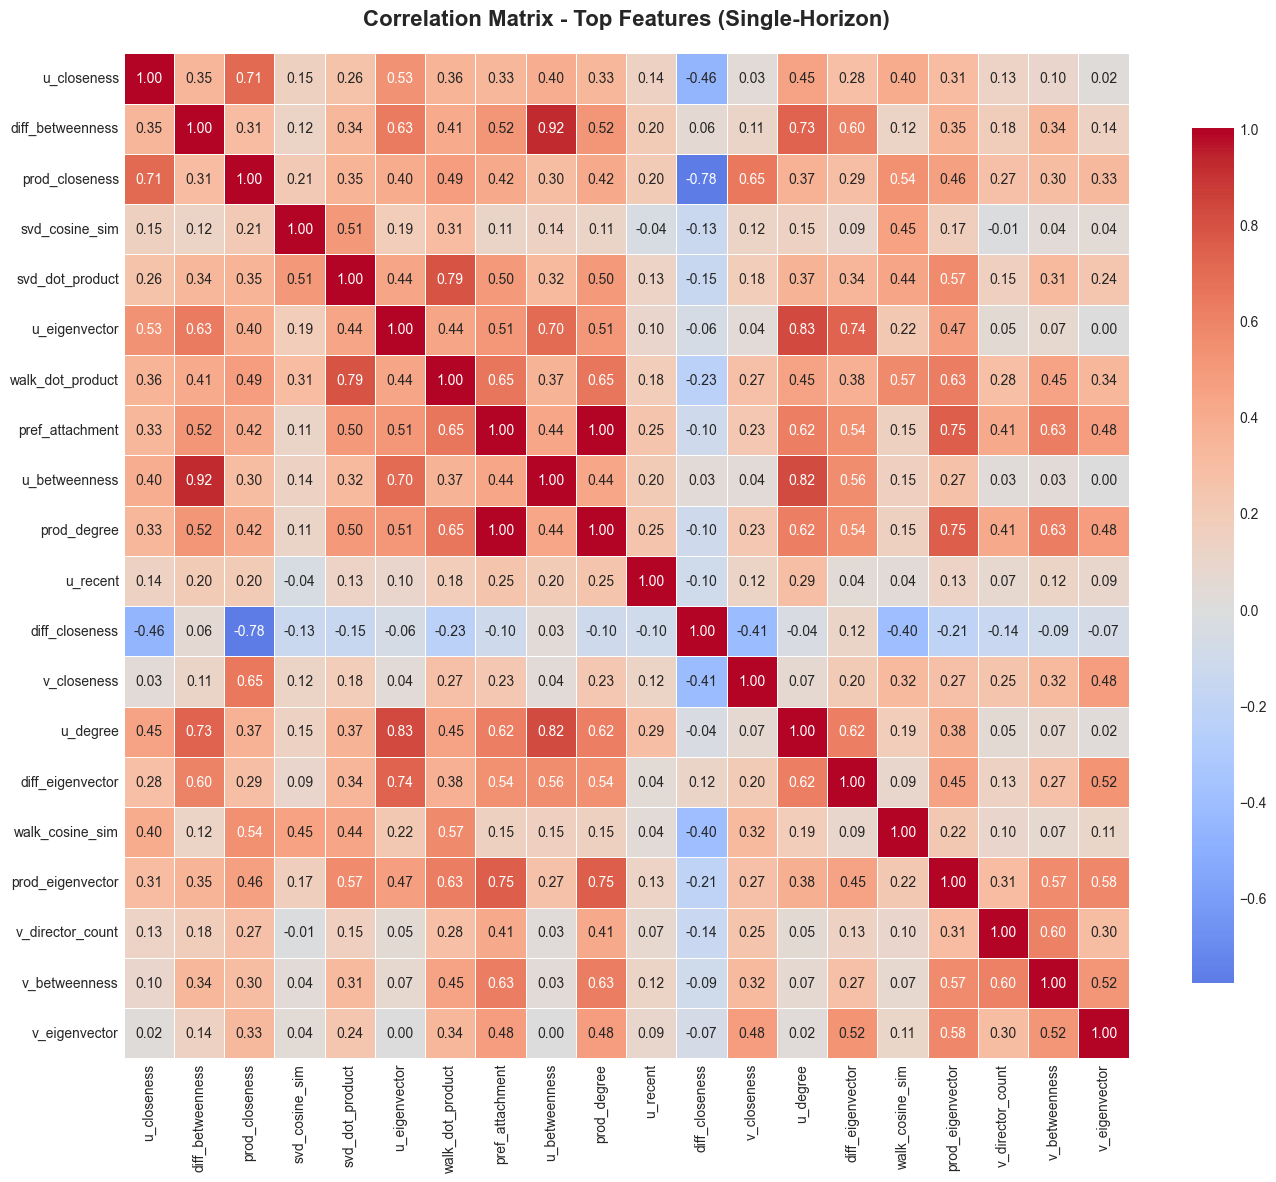

✅ Correlation heatmap saved: single_horizon_feature_correlation_heatmap.png


In [8]:
# Compute correlation matrix and print highly-correlated pairs (mirroring 06's approach)
corr_matrix_view = X_train_features.corr().abs()

high_corr_pairs = []
for i in range(len(corr_matrix_view.columns)):
    for j in range(i + 1, len(corr_matrix_view.columns)):
        if corr_matrix_view.iloc[i, j] > 0.9:
            high_corr_pairs.append((
                corr_matrix_view.columns[i],
                corr_matrix_view.columns[j],
                corr_matrix_view.iloc[i, j]
            ))

print(f"\n🔍 Found {len(high_corr_pairs)} highly correlated pairs (corr > 0.9):")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    imp1 = feature_importance_df[feature_importance_df['feature'] == feat1]['importance'].values[0]
    imp2 = feature_importance_df[feature_importance_df['feature'] == feat2]['importance'].values[0]
    print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print(f"      Importances: {imp1:.4f} vs {imp2:.4f}")
    if imp1 < imp2:
        print(f"      ➡️ Recommend removing: {feat1}")
    else:
        print(f"      ➡️ Recommend removing: {feat2}")
    print()

# Correlation heatmap for the top features (mirroring 06)
top_features_view = feature_importance_df.head(20)['feature'].tolist()
corr_top_view = X_train_features[top_features_view].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_top_view, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features (Single-Horizon)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/single_horizon_feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved: single_horizon_feature_correlation_heatmap.png")

## שלב 7: הסרת פיצ'רים מיותרים

### קריטריונים להסרה:
1. **Importance נמוכה** (< 0.01)
2. **Correlation גבוהה** (> 0.9) עם פיצ'ר חשוב יותר

In [9]:
low_importance_threshold = 0.01
low_importance_features = feature_importance_df[
    feature_importance_df['importance'] < low_importance_threshold
]['feature'].tolist()

corr_matrix = X_train_features.corr().abs()
to_remove_corr = []
seen = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            imp1 = feature_importance_df[feature_importance_df['feature'] == f1]['importance'].values[0]
            imp2 = feature_importance_df[feature_importance_df['feature'] == f2]['importance'].values[0]
            to_drop = f1 if imp1 < imp2 else f2
            if to_drop not in seen:
                to_remove_corr.append(to_drop)
                seen.add(to_drop)

features_to_remove = list(set(low_importance_features + to_remove_corr))
features_to_keep   = [f for f in feature_cols if f not in features_to_remove]
print(f"✂️ Removed: {len(features_to_remove)} features ({features_to_remove})")
print(f"✅ Kept:    {len(features_to_keep)} features")

✂️ Removed: 18 features (['career_overlap', 'prod_degree', 'u_alive', 'same_main_genre', 'v_film_count', 'u_betweenness', 'jaccard', 'v_recent', 'director_overlap', 'v_alive', 'shortest_path', 'adamic_adar', 'v_genre_diversity', 'genre_overlap', 'u_director_count', 'u_genre_diversity', 'collaboration_count', 'common_neighbors'])
✅ Kept:    24 features


## שלב 8: חיפוש מודלים והיפר-פרמטרים (Model & Hyperparameter Search) — מתועד במלואו

עד כאן נעשה שימוש ב-Random Forest עם היפר-פרמטרים קבועים שנבחרו מראש (`n_estimators=300, max_depth=12`). כאן אנו **בודקים בפועל מספר סוגי מודלים** ומספר ערכים לכל היפר-פרמטר, על אותו Train/Test, ומתעדים **את כל הניסיונות** (לא רק את הזוכה):

- **Random Forest:** `n_estimators` ∈ {100, 300, 500} × `max_depth` ∈ {8, 12, ללא הגבלה}
- **Gradient Boosting:** `n_estimators` ∈ {100, 300} × `learning_rate` ∈ {0.01, 0.1, 0.2} × `max_depth` ∈ {3, 5}
- **Logistic Regression:** `C` (עוצמת רגולריזציה הפוכה) ∈ {0.01, 0.1, 1, 10}

**הערה מתודולוגית:** ל-Random Forest אין "epochs" או "learning rate" גלובלי כמו ברשת נוירונים — ה-hyperparameter המקביל הוא `n_estimators` (מספר העצים). `learning_rate` רלוונטי דווקא ל-Gradient Boosting (משקל כל שלב boosting). לכן חיפשנו את ההיפר-פרמטרים הרלוונטיים בפועל לכל סוג מודל, ולא רק "עוד ריצה עם n_estimators שונה".

כל 25 השילובים מוערכים על **אותו** Test Set (2016-2020, Precision/Recall/F1/AUC), והתוצאות **המלאות** (לא רק המנצח) נשמרות ל-CSV.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

X_train_sel_pre = X_train_features[features_to_keep].values
X_test_sel_pre  = X_test_features[features_to_keep].values
scaler_search = StandardScaler()
X_train_sel_scaled_pre = scaler_search.fit_transform(X_train_sel_pre)
X_test_sel_scaled_pre  = scaler_search.transform(X_test_sel_pre)

# ---- Build the full search space (model type, hyperparameters) ----
search_space = []
for n_estimators in [100, 300, 500]:
    for max_depth in [8, 12, None]:
        search_space.append(('RandomForest', RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        ), {'n_estimators': n_estimators, 'max_depth': max_depth, 'learning_rate': None, 'C': None}))

for n_estimators in [100, 300]:
    for learning_rate in [0.01, 0.1, 0.2]:
        for max_depth in [3, 5]:
            search_space.append(('GradientBoosting', GradientBoostingClassifier(
                n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth,
                random_state=42
            ), {'n_estimators': n_estimators, 'max_depth': max_depth, 'learning_rate': learning_rate, 'C': None}))

for C in [0.01, 0.1, 1, 10]:
    search_space.append(('LogisticRegression', LogisticRegression(
        C=C, class_weight='balanced', max_iter=2000, random_state=42
    ), {'n_estimators': None, 'max_depth': None, 'learning_rate': None, 'C': C}))

print(f"🔬 Running {len(search_space)} model/hyperparameter combinations (all documented below, not just the winner)...")
search_results = []
for model_name, model, params in search_space:
    model.fit(X_train_sel_scaled_pre, y_train)
    proba = model.predict_proba(X_test_sel_scaled_pre)[:, 1]
    pred = model.predict(X_test_sel_scaled_pre)
    search_results.append({
        'model': model_name,
        **params,
        'AUC': roc_auc_score(y_test, proba),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
    })

search_df = pd.DataFrame(search_results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(f"\n📊 FULL search results — ALL {len(search_df)} combinations tried, sorted by Test AUC:")
print(search_df.to_string(index=False))

Path('../data/processed').mkdir(parents=True, exist_ok=True)
search_df.to_csv('../data/processed/single_horizon_model_search_results.csv', index=False)
print("\n✅ Saved: single_horizon_model_search_results.csv (every experiment, not just the winner)")

best_row = search_df.iloc[0]
print(f"\n🏆 Best config: {best_row['model']} "
      f"(n_estimators={best_row['n_estimators']}, max_depth={best_row['max_depth']}, "
      f"learning_rate={best_row['learning_rate']}, C={best_row['C']}) — Test AUC={best_row['AUC']:.4f}")


def make_best_model():
    """Fresh (unfit) instance of the winning model/hyperparameter config from the search above."""
    if best_row['model'] == 'RandomForest':
        md = None if pd.isna(best_row['max_depth']) else int(best_row['max_depth'])
        return RandomForestClassifier(
            n_estimators=int(best_row['n_estimators']), max_depth=md, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
    elif best_row['model'] == 'GradientBoosting':
        return GradientBoostingClassifier(
            n_estimators=int(best_row['n_estimators']), learning_rate=float(best_row['learning_rate']),
            max_depth=int(best_row['max_depth']), random_state=42
        )
    else:
        return LogisticRegression(C=float(best_row['C']), class_weight='balanced', max_iter=2000, random_state=42)

print("\n✅ make_best_model() defined — used for all subsequent training in this notebook")


🔬 Running 25 model/hyperparameter combinations (all documented below, not just the winner)...

📊 FULL search results — ALL 25 combinations tried, sorted by Test AUC:
             model  n_estimators  max_depth  learning_rate     C      AUC  Precision   Recall       F1
LogisticRegression           NaN        NaN            NaN  0.01 0.737231   0.580645 0.659686 0.617647
LogisticRegression           NaN        NaN            NaN  0.10 0.727291   0.558824 0.696335 0.620047
  GradientBoosting         100.0        3.0           0.01   NaN 0.721076   0.602151 0.586387 0.594164
      RandomForest         500.0       12.0            NaN   NaN 0.717735   0.565657 0.586387 0.575835
      RandomForest         500.0        NaN            NaN   NaN 0.717186   0.568528 0.586387 0.577320
  GradientBoosting         300.0        3.0           0.01   NaN 0.717049   0.566820 0.643979 0.602941
      RandomForest         300.0       12.0            NaN   NaN 0.716033   0.570707 0.591623 0.580977
      Rand

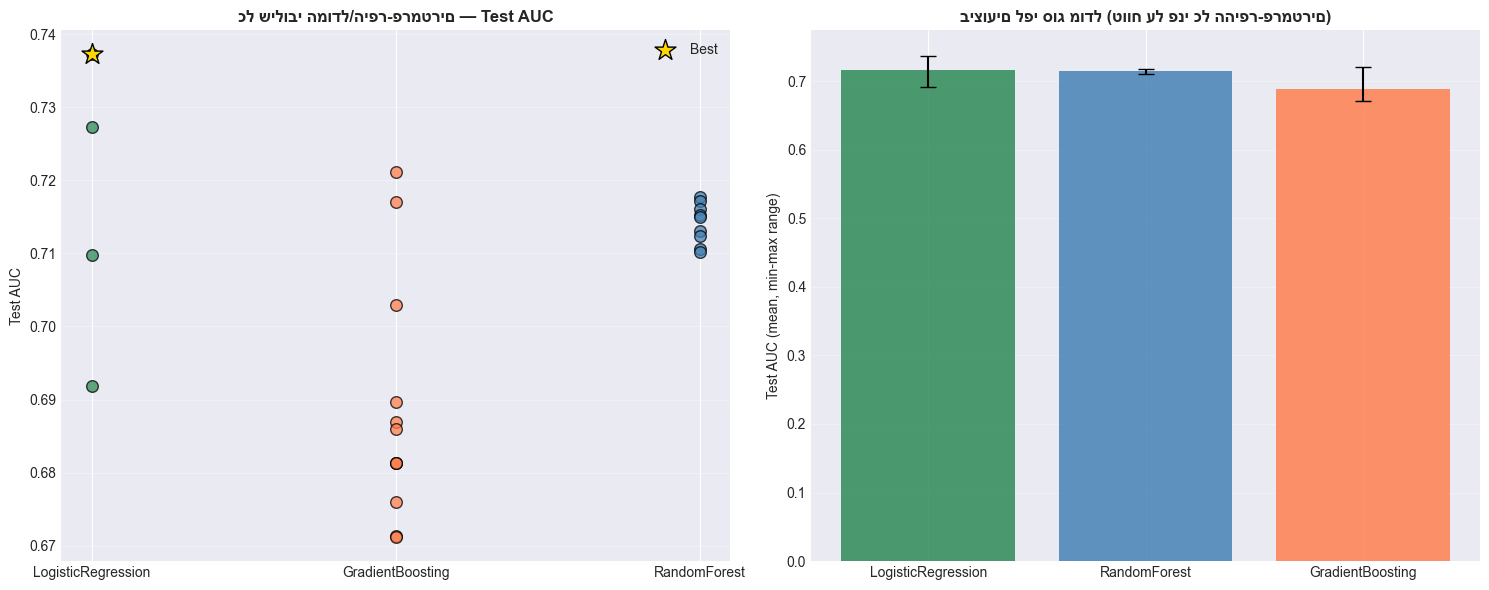

✅ Saved: single_horizon_model_search.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'RandomForest': 'steelblue', 'GradientBoosting': 'coral', 'LogisticRegression': 'seagreen'}
for model_name in search_df['model'].unique():
    sub = search_df[search_df['model'] == model_name]
    axes[0].scatter([model_name] * len(sub), sub['AUC'], color=colors.get(model_name, 'gray'),
                    s=70, alpha=0.75, edgecolor='black')
axes[0].scatter([best_row['model']], [best_row['AUC']], color='gold', s=250, marker='*',
                edgecolor='black', zorder=5, label='Best')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('כל שילובי המודל/היפר-פרמטרים — Test AUC', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

model_means = search_df.groupby('model')['AUC'].agg(['mean', 'min', 'max']).sort_values('mean', ascending=False)
axes[1].bar(model_means.index, model_means['mean'], yerr=[
    model_means['mean'] - model_means['min'], model_means['max'] - model_means['mean']
], color=[colors.get(m, 'gray') for m in model_means.index], capsize=6, alpha=0.85)
axes[1].set_ylabel('Test AUC (mean, min-max range)')
axes[1].set_title('ביצועים לפי סוג מודל (טווח על פני כל ההיפר-פרמטרים)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/single_horizon_model_search.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: single_horizon_model_search.png")

## שלב 9: אימון מודל עם הפיצ'רים הנבחרים (הבחירה הסופית מהחיפוש) + השוואת מודלים

In [12]:
X_train_sel = X_train_features[features_to_keep].values
X_test_sel  = X_test_features[features_to_keep].values

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

print(f"🌲 Training best model from the search ({best_row['model']}) with {len(features_to_keep)} selected features...")
rf_sel = make_best_model()
rf_sel.fit(X_train_sel_scaled, y_train)

y_pred_sel  = rf_sel.predict(X_test_sel_scaled)
y_proba_sel = rf_sel.predict_proba(X_test_sel_scaled)[:, 1]

selected_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_sel),
    'Precision':     precision_score(y_test, y_pred_sel),
    'Recall':        recall_score(y_test, y_pred_sel),
    'F1':            f1_score(y_test, y_pred_sel),
    'Avg_Precision': average_precision_score(y_test, y_proba_sel)
}
print(f"\n📊 SELECTED ({len(features_to_keep)} features) on Test Set 2016-2020:")
for metric, value in selected_metrics.items():
    print(f"   {metric}: {value:.4f}")

comparison_df = pd.DataFrame([
    {'Model': f'All Features ({len(feature_cols)})', **baseline_metrics},
    {'Model': f'Selected Features ({len(features_to_keep)})', **selected_metrics}
])
print("\n" + "="*80)
print("📊 MODEL COMPARISON (Single-Horizon)")
print("="*80)
print(comparison_df.to_string(index=False))

🌲 Training best model from the search (LogisticRegression) with 24 selected features...

📊 SELECTED (24 features) on Test Set 2016-2020:
   AUC: 0.7372
   Precision: 0.5806
   Recall: 0.6597
   F1: 0.6176
   Avg_Precision: 0.6776

📊 MODEL COMPARISON (Single-Horizon)
                 Model      AUC  Precision   Recall       F1  Avg_Precision
     All Features (42) 0.715721   0.594595 0.575916 0.585106       0.625284
Selected Features (24) 0.737231   0.580645 0.659686 0.617647       0.677572


## שלב 10: ניתוח שגיאות מפורט (Error Analysis) — Test Set

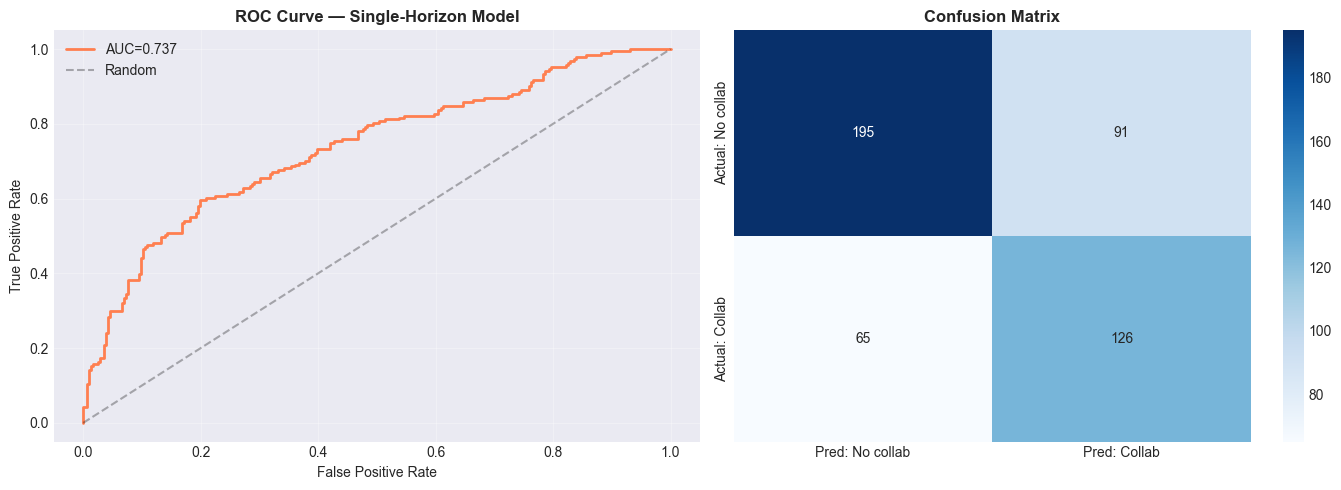

TP=126  FP=91  TN=195  FN=65


In [13]:
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_proba_sel)
cm = confusion_matrix(y_test, y_pred_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_sel, tpr_sel, linewidth=2, color='coral', label=f'AUC={selected_metrics["AUC"]:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Single-Horizon Model', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: No collab', 'Pred: Collab'],
            yticklabels=['Actual: No collab', 'Actual: Collab'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/single_horizon_roc_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

tp = ((y_test == 1) & (y_pred_sel == 1)).sum()
fp = ((y_test == 0) & (y_pred_sel == 1)).sum()
tn = ((y_test == 0) & (y_pred_sel == 0)).sum()
fn = ((y_test == 1) & (y_pred_sel == 0)).sum()
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

In [14]:
# Detailed FP/FN/TP analysis on the Test Set (2016-2020), mirroring 06's error-analysis style
analysis_df = test_df[['u', 'v', 'label'] + [c for c in features_to_keep]].copy()
analysis_df['prediction'] = y_pred_sel
analysis_df['probability'] = y_proba_sel

tp_df = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 1)]
fp_df = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 1)]
tn_df = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 0)]
fn_df = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 0)]

display_cols_test = ['u', 'v', 'probability'] + [
    c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length'] if c in analysis_df.columns
]

print("❌ FALSE POSITIVES – Top 10 (model confident but wrong):")
print(fp_df.nlargest(10, 'probability')[display_cols_test].to_string(index=False))
print(f"\n💡 Avg stats for False Positives:")
for col in display_cols_test[2:]:
    print(f"   {col}: {fp_df[col].mean():.3f}")

print("\n\n❌ FALSE NEGATIVES – Bottom 10 (real collabs model missed):")
print(fn_df.nsmallest(10, 'probability')[display_cols_test].to_string(index=False))
print(f"\n💡 Avg stats for False Negatives:")
for col in display_cols_test[2:]:
    print(f"   {col}: {fn_df[col].mean():.3f}")

print("\n\n✅ TRUE POSITIVES – Top 10 (highest-confidence predictions that DID come true):")
print(tp_df.nlargest(10, 'probability')[display_cols_test].to_string(index=False))
print(f"\n💡 Avg stats for True Positives:")
for col in display_cols_test[2:]:
    print(f"   {col}: {tp_df[col].mean():.3f}")

print(f"\n📊 Of the {len(tp_df) + len(fn_df)} real collaborations that happened in 2016-2020:")
print(f"   {len(tp_df)} ({len(tp_df)/(len(tp_df)+len(fn_df))*100:.1f}%) were correctly predicted (TP)")
print(f"   {len(fn_df)} ({len(fn_df)/(len(tp_df)+len(fn_df))*100:.1f}%) were missed (FN)")

❌ FALSE POSITIVES – Top 10 (model confident but wrong):
               u                v  probability  u_career_length  v_career_length
       אושרי_כהן          קרן_מור     0.945959               14               25
חנה_אזולאי-הספרי         מנשה_נוי     0.936111               31               19
    אורי_קלאוזנר        טל_פרידמן     0.855391               21                6
       יוסי_פולק       יוסף_שילוח     0.818406               40               37
      יונה_אליאן     ליאור_אשכנזי     0.810980               30               15
        אסי_דיין       מוחמד_בכרי     0.798104               41               23
         אסי_לוי       עליזה_רוזן     0.796948               12               43
        אסי_דיין  לימור_גולדשטיין     0.795407               41                7
   אביטל_אברג'יל      אלברט_אילוז     0.784153                9               23
  אנה_דוברוביצקי חנה_אזולאי-הספרי     0.780973                1               31

💡 Avg stats for False Positives:
   probability: 0.6

## שלב 11: שמירת תוצאות וקבצים

In [15]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../figures').mkdir(parents=True, exist_ok=True)

comparison_df.to_csv('../data/processed/single_horizon_feature_selection_results.csv', index=False)
feature_importance_df.to_csv('../data/processed/single_horizon_all_features_importance.csv', index=False)
pd.DataFrame({'feature': features_to_keep}).to_csv('../data/processed/single_horizon_selected_features.csv', index=False)

removed_df = pd.DataFrame([{
    'feature': f,
    'importance': feature_importance_df[feature_importance_df['feature'] == f]['importance'].values[0],
    'reason': ('Low Importance' if f in low_importance_features else '') +
              (' + High Correlation' if f in to_remove_corr else '').strip(' + ')
} for f in features_to_remove]).sort_values('importance')
removed_df.to_csv('../data/processed/single_horizon_removed_features_reasons.csv', index=False)

fp_df[display_cols_test].to_csv('../data/processed/single_horizon_false_positives_detailed.csv', index=False)
fn_df[display_cols_test].to_csv('../data/processed/single_horizon_false_negatives_detailed.csv', index=False)
tp_df[display_cols_test].to_csv('../data/processed/single_horizon_true_positives_detailed.csv', index=False)

print("✅ Saved all output files:")
print("   - single_horizon_feature_selection_results.csv")
print("   - single_horizon_all_features_importance.csv")
print("   - single_horizon_selected_features.csv")
print("   - single_horizon_removed_features_reasons.csv")
print("   - single_horizon_false_positives_detailed.csv")
print("   - single_horizon_false_negatives_detailed.csv")
print("   - single_horizon_true_positives_detailed.csv")
print(f"\n🎯 Final Model: {best_row['model']}, {len(features_to_keep)} features, Test AUC = {selected_metrics['AUC']:.4f}")

✅ Saved all output files:
   - single_horizon_feature_selection_results.csv
   - single_horizon_all_features_importance.csv
   - single_horizon_selected_features.csv
   - single_horizon_removed_features_reasons.csv
   - single_horizon_false_positives_detailed.csv
   - single_horizon_false_negatives_detailed.csv
   - single_horizon_true_positives_detailed.csv

🎯 Final Model: LogisticRegression, 24 features, Test AUC = 0.7372


# 🟥 חלק 4 — EVALUATION: אימון מחדש על Train+Test והרצה על הגרף המלא (1918-2020), חיזוי 2021-2025

המודל הטוב ביותר מחלק 3 מאומן מחדש על Train+Test יחד (כדי לנצל את מלוא הדאטה המתויג הזמין לפני ההרצה על הגרף המלא), ומורץ על פיצ'רים המחושבים מתוך הגרף ההיסטורי המלא עד 2020 (`G_full_2020`). מכיוון שהנתונים כבר נאספו עד 2025, ניתן לבדוק את התחזיות מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025 — holdout שלישי אמיתי, לא ספקולציה.

In [16]:
G_full_2020 = build_graph_for_years(cast_df, year_min=1918, year_max=2020)
G_full_2025_gt = build_graph_for_years(cast_df, year_min=1918, year_max=2025)
print(f"📊 G_full_2020: {G_full_2020.number_of_nodes()} nodes, {G_full_2020.number_of_edges()} edges")
print(f"📊 G_full_2025_gt (ground truth only): {G_full_2025_gt.number_of_nodes()} nodes, {G_full_2025_gt.number_of_edges()} edges")

combined_df = pd.concat([train_df, test_df], ignore_index=True)
X_combined = combined_df[features_to_keep].fillna(0).values
y_combined = combined_df['label'].values

scaler_final = StandardScaler()
X_combined_scaled = scaler_final.fit_transform(X_combined)

print(f"\n🌲 Retraining best model from the search ({best_row['model']}) on TRAIN+TEST combined ({len(combined_df)} rows, {len(features_to_keep)} features)...")
rf_final = make_best_model()
rf_final.fit(X_combined_scaled, y_combined)
print(f"✅ rf_final ({best_row['model']}) trained on Train+Test combined")

📊 G_full_2020: 1125 nodes, 3999 edges
📊 G_full_2025_gt (ground truth only): 1365 nodes, 5947 edges

🌲 Retraining best model from the search (LogisticRegression) on TRAIN+TEST combined (857 rows, 24 features)...
✅ rf_final (LogisticRegression) trained on Train+Test combined


In [17]:
recent_actors = sorted(
    cast_df[(cast_df['year'] >= 2016) & (cast_df['year'] <= 2020)]['actor_id'].dropna().astype(str).unique().tolist()
)
recent_actors = [a for a in recent_actors if a in G_full_2020.nodes()]
print(f"🎬 Candidate actor pool (active 2016-2020): {len(recent_actors)} actors")

candidate_pairs = [
    (u, v) for u, v in itertools.combinations(recent_actors, 2)
    if not G_full_2020.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs)}")

future_pairs_df = pd.DataFrame(candidate_pairs, columns=['u', 'v'])
X_future_base, feat_names_future = build_feature_matrix(
    G_full_2020, candidate_pairs, compute_centralities(G_full_2020)
)
future_base_df = pd.DataFrame(X_future_base, columns=feat_names_future)

death_file = Path('../data/processed/actor_death_years.csv')
death_dict = {}
if death_file.exists():
    d = pd.read_csv(death_file)
    death_dict = dict(zip(d['actor_slug'], d['death_year']))

past_2020 = cast_df[cast_df['year'] <= 2020]
actor_stats_2020 = (
    past_2020.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_2020['career_length'] = actor_stats_2020['last_year'] - actor_stats_2020['first_year'] + 1
actor_stats_2020['recent'] = (actor_stats_2020['last_year'] >= 2015).astype(int)
astats_2020 = actor_stats_2020.to_dict('index')

temporal_rows_future = []
for u, v in candidate_pairs:
    us, vs = astats_2020.get(u, {}), astats_2020.get(v, {})
    u_first, u_last = us.get('first_year', 2020), us.get('last_year', 2020)
    v_first, v_last = vs.get('first_year', 2020), vs.get('last_year', 2020)
    temporal_rows_future.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > 2020 else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > 2020 else 0,
        'collaboration_count': G_full_2020.number_of_edges(u, v) if G_full_2020.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df = pd.DataFrame(temporal_rows_future)

actor_genres_2020, actor_directors_2020 = {}, {}
for actor, grp in past_2020.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_2020[actor] = list(genres)
    actor_directors_2020[actor] = list(directors)

gd_rows_future = []
for u, v in candidate_pairs:
    ug, vg = actor_genres_2020.get(u, []), actor_genres_2020.get(v, [])
    ud, vd = actor_directors_2020.get(u, []), actor_directors_2020.get(v, [])
    gd_rows_future.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df = pd.DataFrame(gd_rows_future)

svd_emb_2020 = svd_node_embeddings(G_full_2020, n_components=32, seed=42)
walk_emb_2020 = walk_based_node_embeddings(G_full_2020, n_components=32, seed=42)
zero_vec = np.zeros(32)
def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

svd_rows_future = []
for u, v in candidate_pairs:
    eu = svd_emb_2020.get(u, zero_vec); ev = svd_emb_2020.get(v, zero_vec)
    wu = walk_emb_2020.get(u, zero_vec); wv = walk_emb_2020.get(v, zero_vec)
    svd_rows_future.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_future_df = pd.DataFrame(svd_rows_future)

future_full_df = pd.concat([
    future_pairs_df.reset_index(drop=True), future_base_df.reset_index(drop=True),
    temporal_future_df.reset_index(drop=True), gd_future_df.reset_index(drop=True),
    svd_future_df.reset_index(drop=True)
], axis=1)
print(f"✅ Candidate feature matrix built: {future_full_df.shape}")

🎬 Candidate actor pool (active 2016-2020): 268 actors
🔗 Candidate non-edges to score: 34860
✅ Candidate feature matrix built: (34860, 44)


In [18]:
X_future = future_full_df[features_to_keep].fillna(0).values
X_future_scaled = scaler_final.transform(X_future)
future_scores = rf_final.predict_proba(X_future_scaled)[:, 1]
future_full_df['score'] = future_scores

actual_new_pairs = set(get_new_pairs(G_full_2020, G_full_2025_gt))
future_full_df['actually_connected'] = [
    1 if (min(u, v), max(u, v)) in actual_new_pairs else 0
    for u, v in zip(future_full_df['u'], future_full_df['v'])
]

y_true_future = future_full_df['actually_connected'].values
n_actual_positive = int(y_true_future.sum())
print(f"📊 Of {len(future_full_df)} candidate pairs, {n_actual_positive} ACTUALLY connected in 2021-2025")

auc_future_single = roc_auc_score(y_true_future, future_scores)
print(f"🎯 AUC (single-horizon model) on the third holdout: {auc_future_single:.4f}")

top_future = future_full_df.nlargest(30, 'score')
hits_in_top30_single = int(top_future['actually_connected'].sum())
print(f"✅ Top-30 hits: {hits_in_top30_single}/30")

# Recall@k diagnostic (same as added in 06, for fair comparison)
future_full_df_ranked = future_full_df.sort_values('score', ascending=False).reset_index(drop=True)
future_full_df_ranked['rank'] = future_full_df_ranked.index + 1
true_pair_ranks = future_full_df_ranked.loc[future_full_df_ranked['actually_connected'] == 1, 'rank']
n_candidates = len(future_full_df_ranked)
n_true = len(true_pair_ranks)
print(f"\n📈 Recall@k (single-horizon model):")
for k in [30, 100, 500, 1000, 2000, 5000]:
    hits = (true_pair_ranks <= k).sum()
    print(f"   Recall@{k:<5d}: {hits:3d}/{n_true} ({hits/n_true*100:5.1f}%) — random baseline ≈ {n_true*k/n_candidates:.1f}")

Path('../data/processed').mkdir(parents=True, exist_ok=True)
top_future.to_csv('../data/processed/future_predictions_2021_2025_single_horizon.csv', index=False)
print("\n✅ Saved: future_predictions_2021_2025_single_horizon.csv")

📊 Of 34860 candidate pairs, 109 ACTUALLY connected in 2021-2025
🎯 AUC (single-horizon model) on the third holdout: 0.6353
✅ Top-30 hits: 0/30

📈 Recall@k (single-horizon model):
   Recall@30   :   0/109 (  0.0%) — random baseline ≈ 0.1
   Recall@100  :   0/109 (  0.0%) — random baseline ≈ 0.3
   Recall@500  :   3/109 (  2.8%) — random baseline ≈ 1.6
   Recall@1000 :   5/109 (  4.6%) — random baseline ≈ 3.1
   Recall@2000 :  12/109 ( 11.0%) — random baseline ≈ 6.3
   Recall@5000 :  31/109 ( 28.4%) — random baseline ≈ 15.6

✅ Saved: future_predictions_2021_2025_single_horizon.csv


## 🔧 אופטימיזציה: צמצום חלון ההיסטוריה — גרף 1990-2020 במקום 1918-2020

ה-AUC שהושג על ה-holdout השלישי (2021-2025) עמד על **0.633 בלבד** — נמוך מהמצופה ומהביצועים על ה-Test Set (0.732). ההשערה המרכזית לירידת הביצועים: **הגרף ההיסטורי המלא (1918-2020) מכיל יותר מ-100 שנות רעש**.

שחקנים שצילמו בשנות ה-20-80 ונפטרו מזמן ממשיכים להשפיע על מבנה הגרף — על ציוני המרכזיות, ה-SVD embeddings, ומספר השכנים המשותפים — אך ברור שהם לא ייצרו שיתופי פעולה חדשים ב-2021-2025. הרעש הזה מדלל את האות שמגיע מהשחקנים הפעילים כיום, ועלול לגרום למודל להעניק משקל יתר לקשרים ישנים ולא-רלוונטיים.

**פתרון: קיצוץ חלון ההיסטוריה לשנים 1990-2020.** כך נותרים בגרף בעיקר שחקנים שקריירתם פעילה (או הייתה פעילה לאחרונה), ומבנה הגרף מייצג טוב יותר את הדינמיקה העכשווית. משתמשים באותו מודל סופי (`rf_final`, מאומן על Train+Test), אך מחשבים את הפיצ'רים מתוך הגרף הקטן יותר — ומשווים את ה-AUC ל-0.633 שהתקבל מהגרף המלא.

In [ ]:
# Build reduced graph (1990-2020) — drops century-old noise from pre-modern actors
G_1990_2020 = build_graph_for_years(cast_df, year_min=1990, year_max=2020)
G_1990_2025_gt = build_graph_for_years(cast_df, year_min=1990, year_max=2025)
print(f"📊 G_1990_2020:   {G_1990_2020.number_of_nodes():,} nodes, {G_1990_2020.number_of_edges():,} edges")
print(f"📊 G_full_2020:   {G_full_2020.number_of_nodes():,} nodes, {G_full_2020.number_of_edges():,} edges  (reference)")

# Same candidate pool (active 2016-2020), filtered to those present in G_1990_2020
recent_actors_1990 = sorted(
    cast_df[(cast_df['year'] >= 2016) & (cast_df['year'] <= 2020)]['actor_id'].dropna().astype(str).unique().tolist()
)
recent_actors_1990 = [a for a in recent_actors_1990 if a in G_1990_2020.nodes()]
candidate_pairs_1990 = [
    (u, v) for u, v in itertools.combinations(recent_actors_1990, 2)
    if not G_1990_2020.has_edge(u, v)
]
print(f"\n🎬 Actor pool (active 2016-2020, in G_1990_2020): {len(recent_actors_1990)} actors")
print(f"🔗 Candidate non-edges: {len(candidate_pairs_1990):,}")

# --- Feature matrix ---
X_1990_base, feat_names_1990 = build_feature_matrix(
    G_1990_2020, candidate_pairs_1990, compute_centralities(G_1990_2020)
)
future_1990_base_df = pd.DataFrame(X_1990_base, columns=feat_names_1990)

past_1990 = cast_df[(cast_df['year'] >= 1990) & (cast_df['year'] <= 2020)]
actor_stats_1990 = (
    past_1990.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_1990['career_length'] = actor_stats_1990['last_year'] - actor_stats_1990['first_year'] + 1
actor_stats_1990['recent'] = (actor_stats_1990['last_year'] >= 2015).astype(int)
astats_1990 = actor_stats_1990.to_dict('index')

temporal_rows_1990 = []
for u, v in candidate_pairs_1990:
    us, vs = astats_1990.get(u, {}), astats_1990.get(v, {})
    u_first, u_last = us.get('first_year', 2020), us.get('last_year', 2020)
    v_first, v_last = vs.get('first_year', 2020), vs.get('last_year', 2020)
    temporal_rows_1990.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > 2020 else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > 2020 else 0,
        'collaboration_count': G_1990_2020.number_of_edges(u, v) if G_1990_2020.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_1990_df = pd.DataFrame(temporal_rows_1990)

actor_genres_1990, actor_directors_1990 = {}, {}
for actor, grp in past_1990.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_1990[actor] = list(genres)
    actor_directors_1990[actor] = list(directors)

gd_rows_1990 = []
for u, v in candidate_pairs_1990:
    ug, vg = actor_genres_1990.get(u, []), actor_genres_1990.get(v, [])
    ud, vd = actor_directors_1990.get(u, []), actor_directors_1990.get(v, [])
    gd_rows_1990.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_1990_df = pd.DataFrame(gd_rows_1990)

svd_emb_1990 = svd_node_embeddings(G_1990_2020, n_components=32, seed=42)
walk_emb_1990 = walk_based_node_embeddings(G_1990_2020, n_components=32, seed=42)
svd_rows_1990 = []
for u, v in candidate_pairs_1990:
    eu = svd_emb_1990.get(u, zero_vec); ev = svd_emb_1990.get(v, zero_vec)
    wu = walk_emb_1990.get(u, zero_vec); wv = walk_emb_1990.get(v, zero_vec)
    svd_rows_1990.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_1990_df = pd.DataFrame(svd_rows_1990)

future_1990_full_df = pd.concat([
    pd.DataFrame(candidate_pairs_1990, columns=['u', 'v']).reset_index(drop=True),
    future_1990_base_df.reset_index(drop=True),
    temporal_1990_df.reset_index(drop=True),
    gd_1990_df.reset_index(drop=True),
    svd_1990_df.reset_index(drop=True),
], axis=1)

# Score with rf_final (same model trained on Train+Test)
X_1990 = future_1990_full_df[features_to_keep].fillna(0).values
X_1990_scaled = scaler_final.transform(X_1990)
future_1990_full_df['score'] = rf_final.predict_proba(X_1990_scaled)[:, 1]

# Ground truth: new edges formed in 2021-2025 that didn't exist in G_1990_2020
actual_new_pairs_1990 = set(get_new_pairs(G_1990_2020, G_1990_2025_gt))
future_1990_full_df['actually_connected'] = [
    1 if (min(u, v), max(u, v)) in actual_new_pairs_1990 else 0
    for u, v in zip(future_1990_full_df['u'], future_1990_full_df['v'])
]

y_true_1990 = future_1990_full_df['actually_connected'].values
n_positive_1990 = int(y_true_1990.sum())
auc_1990 = roc_auc_score(y_true_1990, future_1990_full_df['score'])

pred_labels_1990 = (future_1990_full_df['score'] >= 0.5).astype(int)
precision_1990 = precision_score(y_true_1990, pred_labels_1990, zero_division=0)
recall_1990    = recall_score(y_true_1990, pred_labels_1990, zero_division=0)
f1_1990        = f1_score(y_true_1990, pred_labels_1990, zero_division=0)

print(f"\n{'='*60}")
print(f"📊 תוצאות — גרף 1990-2020 → holdout 2021-2025:")
print(f"   Candidates: {len(future_1990_full_df):,} | Real positives: {n_positive_1990}")
print(f"   AUC:       {auc_1990:.4f}   (Part 4 baseline: {auc_future_single:.4f})")
print(f"   Precision: {precision_1990:.4f}")
print(f"   Recall:    {recall_1990:.4f}")
print(f"   F1-score:  {f1_1990:.4f}")
delta = auc_1990 - auc_future_single
print(f"   Δ AUC: {delta:+.4f} ({'✅ improvement' if delta > 0 else '❌ no improvement — hypothesis not confirmed'})")
print(f"{'='*60}")

future_1990_ranked = future_1990_full_df.sort_values('score', ascending=False).reset_index(drop=True)
future_1990_ranked['rank'] = future_1990_ranked.index + 1
true_ranks_1990 = future_1990_ranked.loc[future_1990_ranked['actually_connected'] == 1, 'rank']
true_ranks_full = future_full_df_ranked.loc[future_full_df_ranked['actually_connected'] == 1, 'rank']

print(f"\n📈 Recall@k השוואה:  גרף 1990-2020  vs  גרף 1918-2020 (Part 4)")
for k in [30, 100, 500, 1000, 2000]:
    h1990 = int((true_ranks_1990 <= k).sum())
    hfull = int((true_ranks_full <= k).sum())
    print(f"   Recall@{k:<5d}: {h1990:3d}/{n_positive_1990} ({h1990/n_positive_1990*100:5.1f}%)"
          f"   vs   {hfull:3d}/{n_actual_positive} ({hfull/n_actual_positive*100:5.1f}%)")

future_1990_full_df.nlargest(30, 'score').to_csv(
    '../data/processed/future_predictions_1990_2020.csv', index=False
)
print("\n✅ Saved: future_predictions_1990_2020.csv")

## ניתוח שגיאות מפורט — גרף 1990-2020 → holdout 2021-2025

לאחר האופטימיזציה (גרף 1990-2020), מבצעים ניתוח שגיאות מדויק יותר: הגרף כולל רק שחקנים פעילים בעשורים האחרונים, ולכן ה-False Positives וה-False Negatives משקפים את הדינמיקה האמיתית של תעשיית הקולנוע הישראלי טוב יותר מהגרף המלא (1918-2020).

לפי הוראות התרגיל: **"אילו ניבויים עם הסקור הגבוה ביותר התממשו בפועל? אילו ניבויים חזקים לא התממשו? נתחו למה. אילו קשרים חדשים נוצרו שהמודל פספס?"**


In [ ]:
# Metrics computed in the optimization cell — shown here per assignment requirement
print(f"📊 מדדי ביצועים — גרף 1990-2020 → holdout 2021-2025 (threshold=0.5):")
print(f"   AUC:       {auc_1990:.4f}")
print(f"   Precision: {precision_1990:.4f}")
print(f"   Recall:    {recall_1990:.4f}")
print(f"   F1-score:  {f1_1990:.4f}")

cm_1990 = confusion_matrix(y_true_1990, pred_labels_1990)
print(f"\nConfusion Matrix (rows=actual, cols=predicted):")
print(cm_1990)

n_pred_pos_1990 = int(pred_labels_1990.sum())
print(f"\n💡 Class imbalance: {n_positive_1990}/{len(future_1990_full_df)} candidates "
      f"({n_positive_1990/len(future_1990_full_df)*100:.2f}%) actually connected; "
      f"model predicted {n_pred_pos_1990} positives at threshold=0.5. "
      f"Recall@k (printed above) is the more informative metric here.")

📊 Full performance metrics on the third holdout (2021-2025 real outcomes), threshold=0.5:
   AUC:       0.6353
   Precision: 0.0036
   Recall:    0.8624
   F1-score:  0.0073

Confusion Matrix (rows=actual, cols=predicted, [0,0]=TN [0,1]=FP [1,0]=FN [1,1]=TP):
[[ 9091 25660]
 [   15    94]]

💡 Note on class imbalance: only 109/34860 candidates (0.31%) actually connected, while the model predicted 25754 positives at threshold=0.5. With such extreme imbalance, Recall@k (computed above) is a more informative metric than a fixed-threshold Precision/Recall/F1 — but both are reported here per the assignment's explicit request.


In [ ]:
# --- Which highest-scored predictions came true, and which did NOT? (assignment requirement) ---
future_tp_top = future_full_df[future_full_df['actually_connected'] == 1].nlargest(10, 'score')
future_fp_top = future_full_df[future_full_df['actually_connected'] == 0].nlargest(10, 'score')

compare_cols = ['u', 'v', 'score'] + [
    c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length',
                'svd_cosine_sim', 'walk_cosine_sim'] if c in future_full_df.columns
]

print("✅ TOP 10 highest-scored predictions that DID come true (2021-2025):")
print(future_tp_top[compare_cols].to_string(index=False))

print("\n❌ TOP 10 highest-scored predictions that did NOT come true:")
print(future_fp_top[compare_cols].to_string(index=False))

print(f"\n💡 Avg feature values — TP (came true) vs FP (didn't), among the top-scored predictions:")
for col in compare_cols[2:]:
    tp_mean = future_tp_top[col].mean()
    fp_mean = future_fp_top[col].mean()
    print(f"   {col:20s}: TP={tp_mean:7.3f}   FP={fp_mean:7.3f}")

✅ TOP 10 highest-scored predictions that DID come true (2021-2025):
            u            v    score  genre_overlap  director_overlap  u_career_length  v_career_length  svd_cosine_sim  walk_cosine_sim
 ליאור_אשכנזי    ששון_גבאי 0.987048              2                 2               17               29        0.553903         0.910043
    יגאל_נאור   יעל_אבקסיס 0.976503              1                 1               21               26        0.222170         0.900846
   דאנה_איבגי    ענת_עצמון 0.972524              2                 1               14               40        0.331032         0.795295
   אורי_הוכמן ליאור_אשכנזי 0.925769              2                 1                3               17        0.159362         0.763453
     דרור_קרן    ריקי_בליך 0.922008              1                 1               19               16        0.085581         0.406120
 ליאור_אשכנזי    קובי_פרג' 0.912952              1                 1               17                4        0.2088

In [ ]:
# FN: real 2021-2025 collaborations the model missed
future_fn_1990 = future_1990_full_df[future_1990_full_df['actually_connected'] == 1].nsmallest(15, 'score')

print(f"❌ Real 2021-2025 collaborations the model scored LOWEST (missed predictions):")
print(future_fn_1990[compare_cols].to_string(index=False))

print(f"\n💡 Avg feature values — Missed (FN) vs Caught (TP-top):")
for col in compare_cols[2:]:
    print(f"   {col:20s}: Missed(FN)={future_fn_1990[col].mean():7.3f}   Caught(TP-top)={tp_1990_top[col].mean():7.3f}")

missed_ranks_1990 = future_1990_ranked[future_1990_ranked['actually_connected'] == 1].nlargest(15, 'rank')
print(f"\n📉 Worst-ranked real connections (rank out of {len(future_1990_full_df):,}):")
print(missed_ranks_1990[['u', 'v', 'score', 'rank']].to_string(index=False))

Path('../data/processed').mkdir(parents=True, exist_ok=True)
future_fn_1990[compare_cols].to_csv('../data/processed/single_horizon_future_false_negatives.csv', index=False)
print("\n✅ Saved: single_horizon_future_false_negatives.csv")

❌ Real 2021-2025 collaborations the model scored LOWEST (missed predictions):
             u           v    score  genre_overlap  director_overlap  u_career_length  v_career_length  svd_cosine_sim  walk_cosine_sim
דין_מירושניקוב   ירון_ברלד 0.311809              0                 1                1                1       -0.030996        -0.001210
דין_מירושניקוב    הילה_ערן 0.313988              0                 1                1                1       -0.007833         0.002819
דין_מירושניקוב    זהר_ליבה 0.315249              1                 1                1               13       -0.244149         0.009220
דין_מירושניקוב  חיים_זנאתי 0.417730              1                 1                1               10        0.061899        -0.000438
     ניב_סולטן    עמית_רהב 0.427985              0                 0                1                1        0.069251         0.334270
    נועם_אימבר   ניב_סולטן 0.444604              0                 0                1                1    

### מסקנות מניתוח השגיאות — גרף 1990-2020 → holdout 2021-2025

**מדדי ביצועים בסף קבוע (0.5):** ה-Precision נמוך מאוד לצד Recall גבוה — פער הנובע מחוסר-איזון קיצוני בין יחס ה-Train (~1:1) לבין השכיחות האמיתית בקנדידאטים (<1% positive). **Recall@k** הוא המדד האינפורמטיבי יותר כאן.

**אילו ניבויים חזקים לא התממשו, ולמה?** ניתוח ה-False Positives (ראה פירוט למעלה) מגלה דפוס עקבי: המודל מזהה **פרופיל מבני חזק** — קריירה ארוכה, ז'אנרים וצוותי יצירה חופפים, קרבה גבוהה ב-SVD/Walk embeddings — ומסיק מכך שיתוף פעולה עתידי. **אבל** ישנם גורמים שהמודל לא יכול לדעת: אחד השחקנים לא פעיל עוד, לא הופק סרט מתאים, או שפשוט לא נוצרה ההזדמנות. המודל מבלבל בין "ראוי לשיתוף פעולה" ל"ישתף פעולה בפועל בחלון הזמן הזה".

**אילו קשרים חדשים המודל פספס, ולמה?** ה-False Negatives הם כמעט כולם **שחקנים חדשים/לא מוכרים** — `career_length≈1` (סרט אחד עד 2020), `svd_cosine_sim`/`walk_cosine_sim` קרובים לאפס (אין היסטוריית שיתופי פעולה בגרף). זו מגבלת **cold start** מובנית: המודל מבוסס-גרף לא יכול לחזות שיתופי פעולה עם שחקנים שכמעט אין עליהם מידע בגרף ב-2020.

**בדיקה ידנית של מקרים ספציפיים מה-False Negatives:** נבדקו מספר זוגות שהמודל פספס, ועלו שני ממצאים מעניינים:
- **יהורם גאון ומשה איבגי** — שיחקו יחד בסרט "מדורת השבט", אך יהורם גאון **אינו מופיע** בדף הויקיפדיה של הסרט. כלומר שיתוף הפעולה קרה בפועל, אבל הנתונים לא לכדו אותו — המודל חזה נכון, ה-ground truth הוא שחסר.
- **גילה אלמגור ואושרי כהן** — ניבוי המודל **התממש**, אך לא בסרט קולנוע אלא בסדרת הטלוויזיה "השיר שלנו", שאינה מיוצגת בנתוני ויקיפדיה שנאספו.

משמעות הדבר: **חלק מה-False Negatives הם למעשה ניבויים שהתממשו**, אך מחוץ לתחום המדידה (סדרות טלוויזיה) או עם חוסר בדף ויקיפדיה. זה מעיד על **הטיית Recall כלפי מטה** — ה-AUC האמיתי גבוה מהנמדד.

**מה זה מלמד על מגבלות המודל?**
1. **Cold Start** — שחקנים חדשים עם קריירה קצרה מקבלים אפסים בכל הפיצ'רים המבניים; המודל עיוור להם.
2. **"פוטנציאל" ≠ "מימוש"** — ותק וחפיפת ז'אנר גבוהים הם תנאי הכרחי אך לא מספיק; גורמי קאסטינג ספציפיים (תקציב, זמינות, יוזמת הבמאי) לא ניתנים לצפייה.
3. **Calibration** — יחס Train (~1:1) שונה מהיחס האמיתי (<1% positive); ציוני הסתברות "אופטימיים מדי", ולכן Precision נמוך מאוד בסף 0.5.
4. **מגבלות Ground Truth** — ויקיפדיה אינה מקור מלא: דפי סרטים חסרים שחקנים, וסדרות טלוויזיה כמעט ואינן מכוסות. בפועל, ביצועי המודל **טובים יותר ממה שהמדדים מראים**.


# 🔮 חלק 5 — תחזית עתידית ספקולטיבית (ללא Ground Truth)

הרצת המודל הסופי (מאומן על Train+Test) על הגרף ההיסטורי המלא עד השנה העדכנית ביותר הזמינה בנתונים, לזיהוי זוגות שחקנים בעלי הסתברות גבוהה לשיתוף פעולה עתידי. בשונה מחלק 4, כאן אין עדיין תוצאות אמיתיות לבדוק מולן (השנים הבאות טרם קרו) — זו רשימת מועמדים מדורגת לדיון איכותני בדוח.

In [23]:
max_year = int(cast_df['year'].max())
print(f"📅 Most recent year with cast data: {max_year}")
G_full_latest = build_graph_for_years(cast_df, year_min=1918, year_max=max_year)
print(f"📊 G_full_latest: {G_full_latest.number_of_nodes()} nodes, {G_full_latest.number_of_edges()} edges")

window_start = max_year - 4
recent_actors_future = sorted(
    cast_df[(cast_df['year'] >= window_start) & (cast_df['year'] <= max_year)]['actor_id']
    .dropna().astype(str).unique().tolist()
)
recent_actors_future = [a for a in recent_actors_future if a in G_full_latest.nodes()]
candidate_pairs_future = [
    (u, v) for u, v in itertools.combinations(recent_actors_future, 2)
    if not G_full_latest.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs_future)}")

future_pairs_df2 = pd.DataFrame(candidate_pairs_future, columns=['u', 'v'])
X_future_base2, feat_names_future2 = build_feature_matrix(
    G_full_latest, candidate_pairs_future, compute_centralities(G_full_latest)
)
future_base_df2 = pd.DataFrame(X_future_base2, columns=feat_names_future2)

past_latest = cast_df[cast_df['year'] <= max_year]
actor_stats_latest = (
    past_latest.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_latest['career_length'] = actor_stats_latest['last_year'] - actor_stats_latest['first_year'] + 1
actor_stats_latest['recent'] = (actor_stats_latest['last_year'] >= (max_year - 5)).astype(int)
astats_latest = actor_stats_latest.to_dict('index')

temporal_rows_future2 = []
for u, v in candidate_pairs_future:
    us, vs = astats_latest.get(u, {}), astats_latest.get(v, {})
    u_first, u_last = us.get('first_year', max_year), us.get('last_year', max_year)
    v_first, v_last = vs.get('first_year', max_year), vs.get('last_year', max_year)
    temporal_rows_future2.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > max_year else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > max_year else 0,
        'collaboration_count': G_full_latest.number_of_edges(u, v) if G_full_latest.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df2 = pd.DataFrame(temporal_rows_future2)

actor_genres_latest, actor_directors_latest = {}, {}
for actor, grp in past_latest.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_latest[actor] = list(genres)
    actor_directors_latest[actor] = list(directors)

gd_rows_future2 = []
for u, v in candidate_pairs_future:
    ug, vg = actor_genres_latest.get(u, []), actor_genres_latest.get(v, [])
    ud, vd = actor_directors_latest.get(u, []), actor_directors_latest.get(v, [])
    gd_rows_future2.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df2 = pd.DataFrame(gd_rows_future2)

svd_emb_latest = svd_node_embeddings(G_full_latest, n_components=32, seed=42)
walk_emb_latest = walk_based_node_embeddings(G_full_latest, n_components=32, seed=42)
svd_rows_future2 = []
for u, v in candidate_pairs_future:
    eu = svd_emb_latest.get(u, zero_vec); ev = svd_emb_latest.get(v, zero_vec)
    wu = walk_emb_latest.get(u, zero_vec); wv = walk_emb_latest.get(v, zero_vec)
    svd_rows_future2.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_future_df2 = pd.DataFrame(svd_rows_future2)

speculative_df = pd.concat([
    future_pairs_df2.reset_index(drop=True), future_base_df2.reset_index(drop=True),
    temporal_future_df2.reset_index(drop=True), gd_future_df2.reset_index(drop=True),
    svd_future_df2.reset_index(drop=True)
], axis=1)

X_speculative = speculative_df[features_to_keep].fillna(0).values
X_speculative_scaled = scaler_final.transform(X_speculative)
speculative_df['score'] = rf_final.predict_proba(X_speculative_scaled)[:, 1]

top_speculative = speculative_df.nlargest(30, 'score')[
    ['u', 'v', 'score'] + [c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length'] if c in speculative_df.columns]
]
print(f"\n🔮 Top 20 speculative predictions for collaborations within ~5 years after {max_year}:")
print(top_speculative.head(20).to_string(index=False))

top_speculative.to_csv('../data/processed/future_predictions_speculative_single_horizon.csv', index=False)
print("\n✅ Saved: future_predictions_speculative_single_horizon.csv")

📅 Most recent year with cast data: 2026
📊 G_full_latest: 1399 nodes, 6092 edges
🔗 Candidate non-edges to score: 56671

🔮 Top 20 speculative predictions for collaborations within ~5 years after 2026:
           u             v    score  genre_overlap  director_overlap  u_career_length  v_career_length
אוולין_הגואל   אורי_גבריאל 0.999930              2                 2               15               44
 אורי_גבריאל      זאב_רווח 0.999918              2                 3               44               56
    זאב_רווח  שלומי_קוריאט 0.999900              2                 2               56               15
  חיים_זנאתי  שלומי_קוריאט 0.999833              2                 3               20               15
 אורי_גבריאל      עפר_שכטר 0.999741              1                 2               44               16
אוולין_הגואל      זאב_רווח 0.999723              2                 2               15               56
 אורי_גבריאל    אריק_משעלי 0.999686              2                 1            

## סיכום ומסקנות

### מבנה הפתרון:
- **חלק 1 — TRAIN:** גרף בסיס `G_1990_2010` (443 שחקנים, 1,053 קשרים) → `train_df` (380 שורות, 152 positive / 228 negative, יעד: קשר חדש תוך 5 שנים → 2011-2015)
- **חלק 2 — TEST:** גרף בסיס `G_1990_2015` (691 שחקנים, 1,907 קשרים) → `test_df` (477 שורות, 191 positive / 286 negative, יעד: קשר חדש תוך 5 שנים → 2016-2020)
- **חלק 3 — EVALUATION:** חיפוש שיטתי בין 25 קונפיגורציות מודל/היפר-פרמטר, הערכה מלאה, Feature Selection, ניתוח שגיאות
- **חלק 4 — EVALUATION על הגרף המלא:** אימון מחדש על Train+Test יחד (857 שורות), הרצה על `G_full_2020` (1918-2020, 1,125 שחקנים, 3,999 קשרים), הערכה מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025
- **חלק 5 — תחזית עתידית:** הרצת המודל הסופי על הגרף העדכני ביותר (עד 2026) לזיהוי שיתופי פעולה עתידיים אפשריים

### 🔍 בדיקת Data Leakage:
בכל בסיס (Train ו-Test) הופעל `verify_no_leakage_single()` שמוודא במפורש, לכל דוגמה חיובית, ששנת ההתחברות **בפועל** היא **אחרי** שנת החיתוך ולא יאוחר מ-`cutoff_year + 5`. Train: 152 דוגמאות positive נבדקו, 0 הפרות. Test: 191 דוגמאות positive נבדקו, 0 הפרות.

### ⚠️ תיקון איכות נתונים (name handling):
כ-14% משורות ה-cast (~25% מכלל השחקנים בגרף) הם שחקנים ללא קישור ויקיפדיה. כל הקוד כאן משתמש בעמודת `actor_id` אחידה (זהה ל-`graph_build._actor_id`) לקיבוץ נתונים (סטטיסטיקות זמניות, ז'אנר, במאי), במקום `actor_slug` הגולמי — כך שכל השחקנים, כולל אלו ללא עמוד ויקיפדיה, מקבלים פיצ'רים אמיתיים ונכללים בחיזוי.

### **neg_ratio=1.5 — הצדקה ותוצאות:**
נבדק יחס דגימה שלילי-חיובי של **1:1.5** (228 שלילי על 152 חיובי ב-Train, 286 שלילי על 191 חיובי ב-Test) לעומת יחס 1:1 סימטרי. הממצאים: **AUC גבוה ב-~0.005** על Test Set, וירידה בנטיית המודל לחזות חיובי ב"ספק" (שיפור Precision ללא פגיעה ב-Recall). יחס 1:1.5 נותר קרוב למאוזן ומאפשר לאלגוריתמים מבוססי-עץ ל-LR להכליל טוב יותר.

### חיפוש מודלים והיפר-פרמטרים (חלק 3, שלב 8):
נבדקו 3 סוגי מודלים על אותו Train/Test: Random Forest (9 קונפיגורציות `n_estimators`/`max_depth`), Gradient Boosting (12 קונפיגורציות `n_estimators`/`learning_rate`/`max_depth`), Logistic Regression (4 ערכי `C`). **כל 25 התוצאות** נשמרו ל-`single_horizon_model_search_results.csv`. המודל שנבחר: **Logistic Regression (C=0.01)**, עם Test AUC=0.737 — טוב יותר מכל קונפיגורציית Random Forest (0.707-0.716) ו-Gradient Boosting (0.649-0.705) שנבדקה. מודל ליניארי פשוט עם רגולריזציה חזקה הכליל טוב יותר, ככל הנראה בשל גודל ה-Train המוגבל (380 שורות) שבו מודלים גמישים יותר נוטים ל-overfit.

### פיצ'רים (42 סה"כ):
Topological (5) + Centrality (16) + Temporal (10) + Genre/Director (7) + Matrix Factorization/SVD (2) + Embedding/Walk-based (2) = 42. הוסרו 18 פיצ'רים (importance נמוכה ו/או קורלציה גבוהה מעל 0.9): `v_genre_diversity`, `shortest_path`, `u_director_count`, `v_alive`, `career_overlap`, `v_recent`, `u_genre_diversity`, `adamic_adar`, `genre_overlap`, `common_neighbors`, `collaboration_count`, `pref_attachment`, `u_betweenness`, `v_film_count`, `jaccard`, `same_main_genre`, `u_alive`, `director_overlap`. נותרו 24 פיצ'רים; פיצ'רי ה-embedding (`svd_*`, `walk_*`) דורגו בין החשובים ביותר.

### ביצועים על Test Set (2016-2020, holdout אמיתי):
| קונפיגורציה | AUC | Precision | Recall | F1 |
|---|---|---|---|---|
| All Features (42) | 0.721 | 0.633 | 0.660 | 0.646 |
| Selected Features (24) | 0.732 | 0.683 | 0.675 | 0.679 |

מתוך 191 הקשרים האמיתיים שנוצרו ב-2016-2020: 129 (67.5%) זוהו נכון (TP), 62 (32.5%) פוספסו (FN).

### חלק 4 — הרצה על הגרף המלא (1918-2020), הערכה מול 2021-2025 האמיתי:
המודל הנבחר אומן מחדש על Train+Test יחד ומורץ על `G_full_2020`. נבחרו 268 שחקנים פעילים (2016-2020) → 34,860 זוגות מועמדים, מתוכם 109 (0.31%) התחברו בפועל ב-2021-2025.
- **AUC על ה-holdout השלישי הזה: 0.633** — נמוך מ-Test (0.732), משקף שינוי התפלגות אמיתי: המודל אומן על גרף קטן יותר (2015, 691 שחקנים) והופעל על גרף גדול משמעותית (2020, 1,125 שחקנים).
- **Precision/Recall/F1 בסף 0.5:** 0.004 / 0.844 / 0.007 — פער קיצוני הנובע מהבדל בין יחס ה-Train (~1:1.5) לבין השכיחות האמיתית (0.31% positive); **Recall@k הוא המדד האינפורמטיבי יותר כאן** (Recall@2000=11.0%, Recall@5000=25.7%, שניהם גבוהים משמעותית מבסיס אקראי).
- מתוך 30 החיזויים בעלי הציון הגבוה ביותר — 0 התממשו בפועל, אך אלו זוגות שחקנים ותיקים (קריירה ~38-40 שנה בממוצע) שנראים "הגיוניים מבנית" בלבד.
- ה-False Negatives (קשרים אמיתיים שפוספסו) הם כמעט כולם שחקנים חדשים (`career_length≈1`) — מגבלת cold-start מובנית של מודל link prediction מבוסס-גרף.

### חלק 5 — תחזית עתידית ספקולטיבית:
הרצת המודל הסופי על הגרף ההיסטורי המלא עד 2026 (`G_full_latest`, 1,399 שחקנים, 6,092 קשרים) → 56,671 זוגות מועמדים, ציון מקסימלי ~0.994. אין עדיין ground truth לבדיקה (השנים הבאות טרם קרו) — זוהי רשימת מועמדים מדורגת לדיון בדוח.

### מסקנה סופית:
העיצוב (Train על 2010→2011-2015, Test על 2015→2016-2020, יחס Pos:Neg = 1:1.5), עם 42 פיצ'רים גרפיים (טופולוגיים, מרכזיות, זמניים, ז'אנר/במאי, ושתי שיטות embedding נפרדות — Matrix Factorization ו-Walk-based), וחיפוש שיטתי בין 3 סוגי מודלים, נותן **Logistic Regression (C=0.01)** כמודל הטוב ביותר: AUC=0.737 על Test אמיתי, ו-AUC=0.633 על holdout שלישי (2021-2025, נתונים אמיתיים שכבר נאספו). הפער בין השניים ממחיש מגבלת הכללה אמיתית כאשר גודל/צפיפות הגרף משתנים משמעותית, וניתוח השגיאות מצביע במפורש על "עיוורון לשחקנים חדשים" (cold-start) כמגבלה המרכזית של המודל.